# 📊 Comprehensive EDA: LLM Benchmark Comparison 2025–2026

**Dataset:** 24 Large Language Models across 10 organizations, 5 countries  
**Goal:** Full exploratory data analysis covering benchmarks, pricing, speed, architecture, and the global AI race.

**Key Questions We'll Answer:**
1. Which model gives the best performance per dollar?
2. Is open source catching up to proprietary models?
3. Which country is winning the AI race in 2025–2026?
4. Can we predict SWE-Bench score from MMLU score?
5. Does larger context window hurt performance?
6. How do models cluster by capability profile?


In [ ]:
# 1. IMPORTS & CONFIGURATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("All libraries imported successfully!")


All libraries imported successfully!


In [ ]:
# 2. LOAD DATA
# For Kaggle, upload the CSV to the input folder or use:
# df = pd.read_csv('llm_benchmark_comparison_2025_2026.csv')

df = pd.read_csv('llm_benchmark_comparison_2025_2026.csv')

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Duplicated rows: {df.duplicated().sum()}")
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")


Shape: 24 rows x 31 columns
Duplicated rows: 0

Column Names:
    1. rank
    2. model_name
    3. organization
    4. country
    5. release_year
    6. release_month
    7. type
    8. architecture
    9. modality
   10. open_source
   11. parameters_b
   12. context_window_k
   13. input_price_per_1m
   14. output_price_per_1m
   15. mmlu
   16. humaneval
   17. gpqa_diamond
   18. swe_bench
   19. hellaswag
   20. aime_2025
   21. speed_tok_s
   22. latency_s
   23. reasoning_model
   24. multimodal
   25. best_for
   26. license
   27. overall_benchmark_avg
   28. performance_per_dollar
   29. speed_tier
   30. price_tier
   31. context_tier


In [ ]:

# 3. DATA TYPES & MISSING VALUES
print("Data Types:")
print(df.dtypes)
print("\n" + "="*60)
print("Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df if len(missing_df) > 0 else "   No missing values!")


Data Types:
rank                        int64
model_name                 object
organization               object
country                    object
release_year                int64
release_month               int64
type                       object
architecture               object
modality                   object
open_source                  bool
parameters_b              float64
context_window_k            int64
input_price_per_1m        float64
output_price_per_1m       float64
mmlu                      float64
humaneval                 float64
gpqa_diamond              float64
swe_bench                 float64
hellaswag                 float64
aime_2025                 float64
speed_tok_s                 int64
latency_s                 float64
reasoning_model              bool
multimodal                   bool
best_for                   object
license                    object
overall_benchmark_avg     float64
performance_per_dollar    float64
speed_tier                 object
pr

In [ ]:
# 4. QUICK PROFILE — NUMERIC COLUMNS

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric Columns Summary:")
df[numeric_cols].describe().round(2).T


Numeric Columns Summary:


,count,mean,std,min,25%,50%,75%,max
rank,24.0,12.50,7.07,1.00,6.75,12.50,18.25,24.0
release_year,24.0,2024.92,0.28,2024.00,2025.00,2025.00,2025.00,2025.0
release_month,24.0,6.12,2.80,1.00,4.00,5.50,8.00,12.0
parameters_b,10.0,215.00,265.81,4.00,34.00,90.50,330.75,671.0
context_window_k,24.0,832.67,2031.80,32.00,128.00,200.00,550.00,10000.0
input_price_per_1m,24.0,2.56,4.37,0.00,0.13,0.80,2.62,15.0
output_price_per_1m,24.0,12.04,21.33,0.00,0.39,3.60,14.25,75.0
mmlu,24.0,87.10,5.81,68.20,86.22,88.50,90.05,93.0
humaneval,24.0,90.01,6.32,70.10,88.40,91.30,93.68,97.5
gpqa_diamond,24.0,73.27,16.20,35.40,63.68,74.90,87.85,94.3


In [ ]:
# 5. QUICK PROFILE — CATEGORICAL COLUMNS
categorical_cols = ['organization', 'country', 'type', 'architecture', 'modality', 
                    'open_source', 'reasoning_model', 'multimodal', 'license',
                    'speed_tier', 'price_tier', 'context_tier']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()}:")
        print(df[col].value_counts().head(10))
        print("-" * 40)



ORGANIZATION:
organization
OpenAI             4
Google DeepMind    4
Anthropic          4
Meta               3
DeepSeek           2
Mistral AI         2
Alibaba            1
xAI                1
MiniMax            1
Zhipu AI           1
Name: count, dtype: int64
----------------------------------------

COUNTRY:
country
USA       17
China      5
France     2
Name: count, dtype: int64
----------------------------------------

TYPE:
type
Proprietary    13
Open Source     7
Open Weight     4
Name: count, dtype: int64
----------------------------------------

ARCHITECTURE:
architecture
Transformer                18
MoE                         5
Transformer (Reasoning)     1
Name: count, dtype: int64
----------------------------------------

MODALITY:
modality
Multimodal    13
Text          10
Text+Code      1
Name: count, dtype: int64
----------------------------------------

OPEN_SOURCE:
open_source
False    13
True     11
Name: count, dtype: int64
---------------------------------------

In [ ]:
# 6. DATA CLEANING & FEATURE ENGINEERING


# Create a working copy
df_clean = df.copy()

# 6.1 Handle missing parameters_b (proprietary models don't disclose)
df_clean['parameters_b'] = df_clean['parameters_b'].fillna(-1)
df_clean['parameters_disclosed'] = df_clean['parameters_b'].apply(lambda x: 'Disclosed' if x > 0 else 'Undisclosed')

# 6.2 Create price features
df_clean['avg_price_per_1m'] = (df_clean['input_price_per_1m'] + df_clean['output_price_per_1m']) / 2

# 6.3 Create benchmark score groups
benchmark_cols = ['mmlu', 'humaneval', 'gpqa_diamond', 'swe_bench', 'hellaswag', 'aime_2025']
df_clean['avg_benchmark'] = df_clean[benchmark_cols].mean(axis=1)

# 6.4 Create efficiency score (performance / latency)
df_clean['efficiency_score'] = df_clean['overall_benchmark_avg'] / df_clean['latency_s']

# 6.5 Categorize by model accessibility
df_clean['accessibility'] = df_clean['type'].map({
    'Open Source': 'Open Source',
    'Open Weight': 'Open Weight', 
    'Proprietary': 'Proprietary'
})

print("Data cleaning complete!")
print(f"   - Derived columns added: avg_price_per_1m, efficiency_score, accessibility, parameters_disclosed")
print(f"   - Benchmark average recalculated from 6 core benchmarks")
df_clean[['model_name', 'parameters_b', 'avg_price_per_1m', 'efficiency_score', 'accessibility']].head()


Data cleaning complete!
   - Derived columns added: avg_price_per_1m, efficiency_score, accessibility, parameters_disclosed
   - Benchmark average recalculated from 6 core benchmarks


,model_name,parameters_b,avg_price_per_1m,efficiency_score,accessibility
0,GPT-5.2,-1.0,7.875,106.235294,Proprietary
1,GPT-5.3 Codex,-1.0,9.000,80.563636,Proprietary
2,Gemini 3.1 Pro,-1.0,3.125,125.305556,Proprietary
3,Claude Opus 4.6,-1.0,45.000,59.733333,Proprietary
4,Claude Opus 4.5,-1.0,45.000,55.512500,Proprietary


## 📈 PART A: UNIVARIATE ANALYSIS

Understanding the distribution of individual variables.

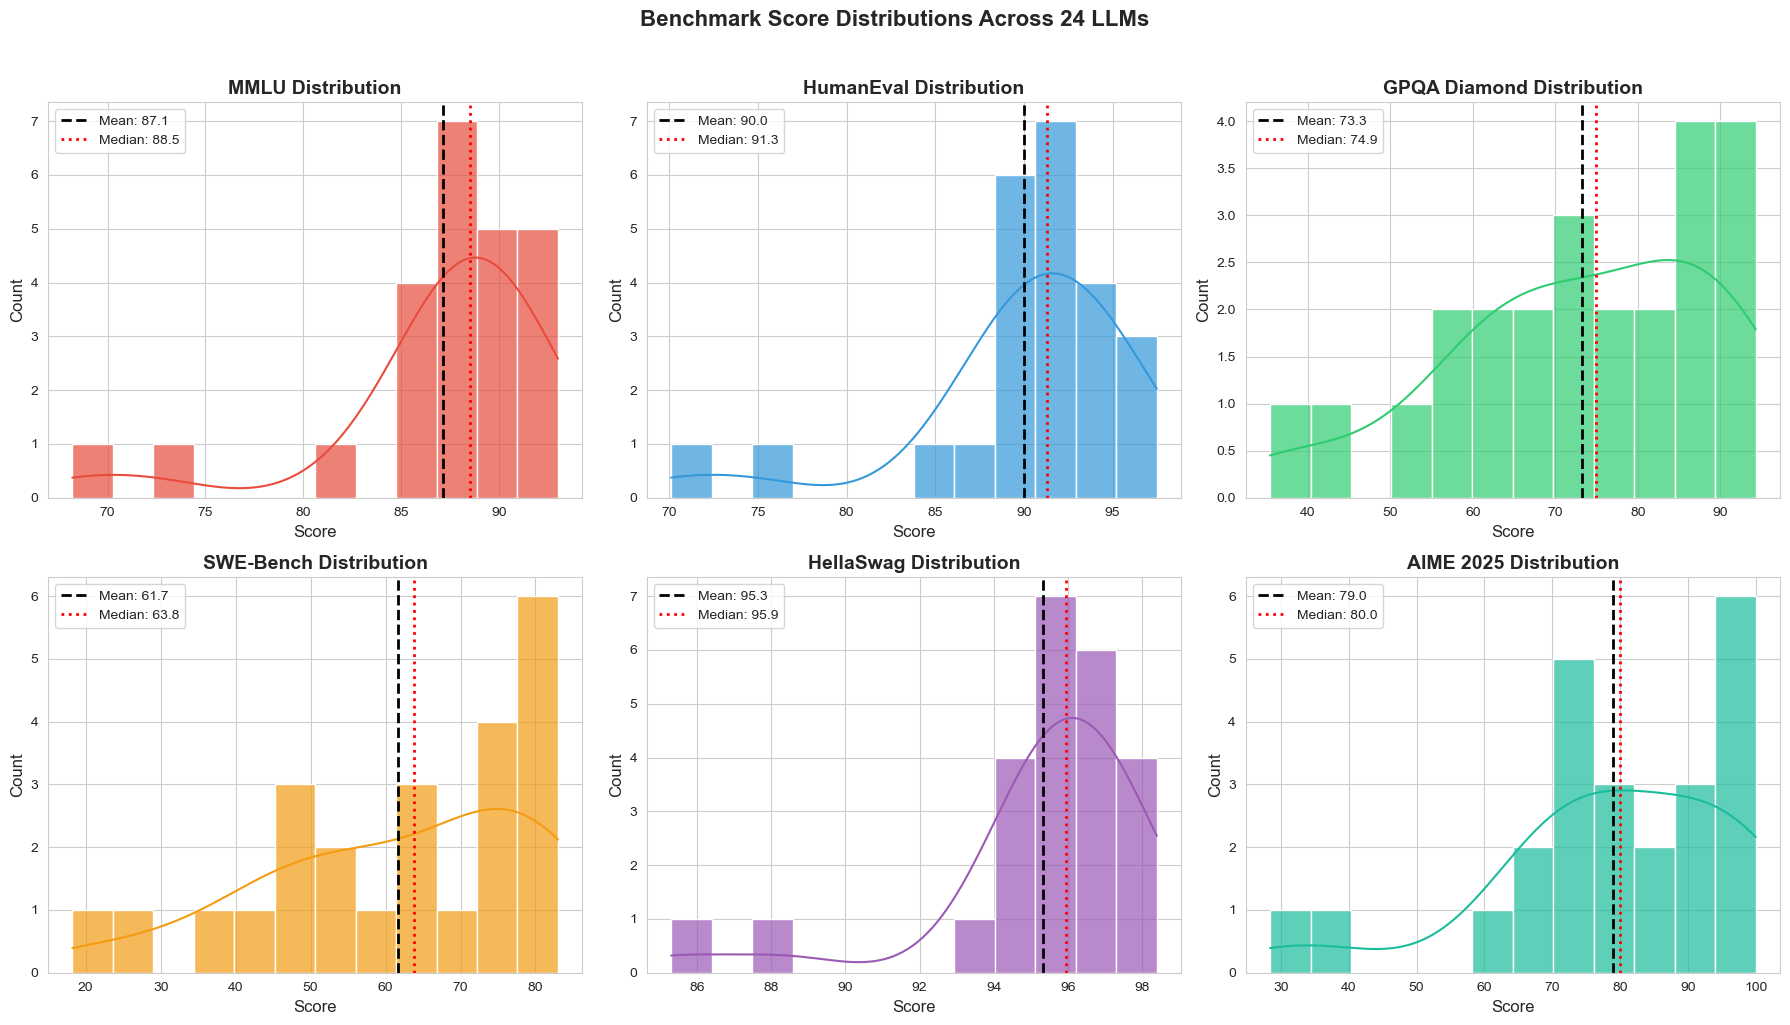

Benchmark Statistics:
              count   mean    std   min    25%    50%    75%    max
mmlu           24.0  87.10   5.81  68.2  86.22  88.50  90.05   93.0
humaneval      24.0  90.01   6.32  70.1  88.40  91.30  93.68   97.5
gpqa_diamond   24.0  73.27  16.20  35.4  63.68  74.90  87.85   94.3
swe_bench      24.0  61.72  18.27  18.2  49.12  63.85  77.60   83.0
hellaswag      24.0  95.33   2.92  85.3  95.02  95.95  96.95   98.4
aime_2025      24.0  78.95  18.55  28.4  71.08  80.05  93.48  100.0


In [ ]:

# 7. BENCHMARK SCORE DISTRIBUTIONS

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

benchmarks = ['mmlu', 'humaneval', 'gpqa_diamond', 'swe_bench', 'hellaswag', 'aime_2025']
benchmark_labels = ['MMLU', 'HumanEval', 'GPQA Diamond', 'SWE-Bench', 'HellaSwag', 'AIME 2025']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for i, (col, label, color) in enumerate(zip(benchmarks, benchmark_labels, colors)):
    ax = axes[i]
    sns.histplot(df_clean[col], kde=True, bins=12, color=color, ax=ax, alpha=0.7)
    ax.axvline(df_clean[col].mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {df_clean[col].mean():.1f}')
    ax.axvline(df_clean[col].median(), color='red', linestyle=':', linewidth=2, label=f'Median: {df_clean[col].median():.1f}')
    ax.set_title(f'{label} Distribution', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Benchmark Score Distributions Across 24 LLMs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Benchmark Statistics:")
print(df_clean[benchmarks].describe().round(2).T)


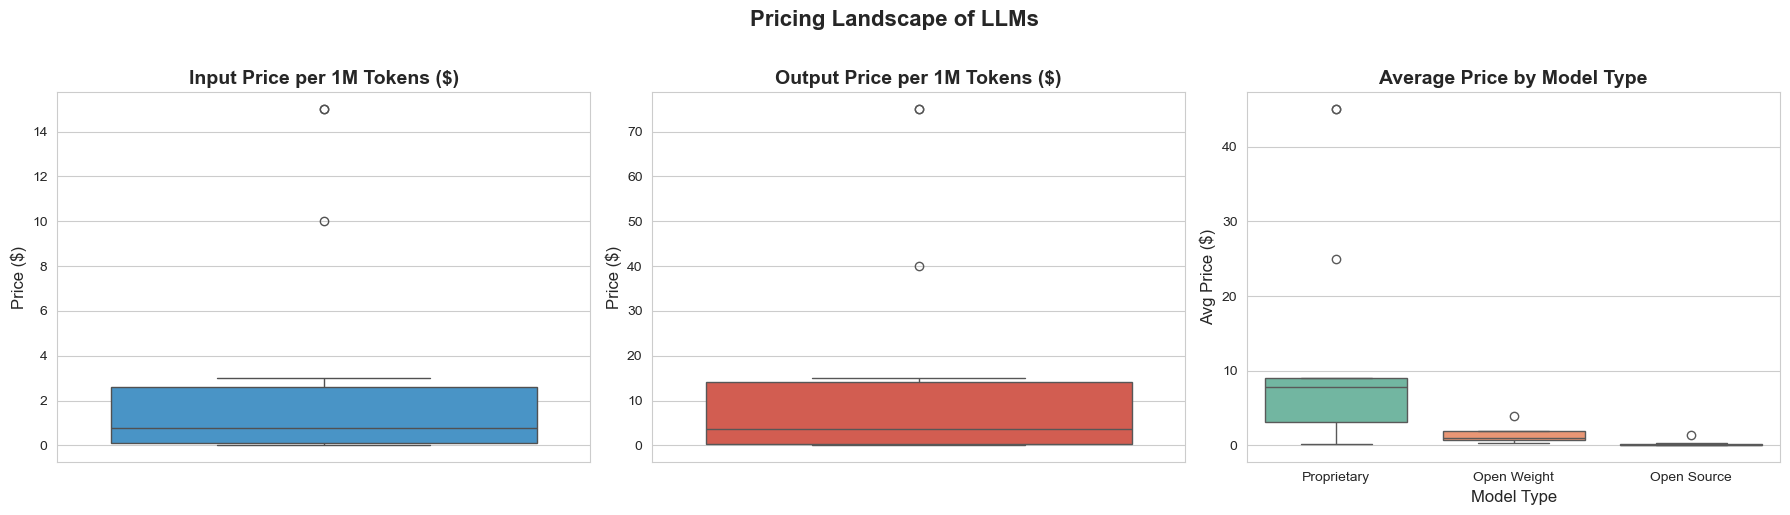

Pricing Summary by Type:
            input_price_per_1m                      output_price_per_1m  \
                          mean median    min    max                mean   
type                                                                      
Open Source              0.127   0.03  0.000   0.55               0.386   
Open Weight              0.762   0.45  0.150   2.00               2.450   
Proprietary              4.417   2.50  0.075  15.00              21.269   

                               avg_price_per_1m                       
            median  min    max             mean median    min    max  
type                                                                  
Open Source   0.03  0.0   2.19            0.256  0.030  0.000   1.37  
Open Weight   1.60  0.6   6.00            1.606  1.025  0.375   4.00  
Proprietary  14.00  0.3  75.00           12.843  7.875  0.188  45.00  


In [ ]:

# 8. PRICING ANALYSIS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Input price
sns.boxplot(y=df_clean['input_price_per_1m'], color='#3498db', ax=axes[0])
axes[0].set_title('Input Price per 1M Tokens ($)', fontweight='bold')
axes[0].set_ylabel('Price ($)')

# Output price
sns.boxplot(y=df_clean['output_price_per_1m'], color='#e74c3c', ax=axes[1])
axes[1].set_title('Output Price per 1M Tokens ($)', fontweight='bold')
axes[1].set_ylabel('Price ($)')

# Average price by type
sns.boxplot(x='type', y='avg_price_per_1m', data=df_clean, palette='Set2', ax=axes[2])
axes[2].set_title('Average Price by Model Type', fontweight='bold')
axes[2].set_ylabel('Avg Price ($)')
axes[2].set_xlabel('Model Type')

plt.suptitle('Pricing Landscape of LLMs', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Pricing Summary by Type:")
print(df_clean.groupby('type')[['input_price_per_1m', 'output_price_per_1m', 'avg_price_per_1m']].agg(['mean', 'median', 'min', 'max']).round(3))


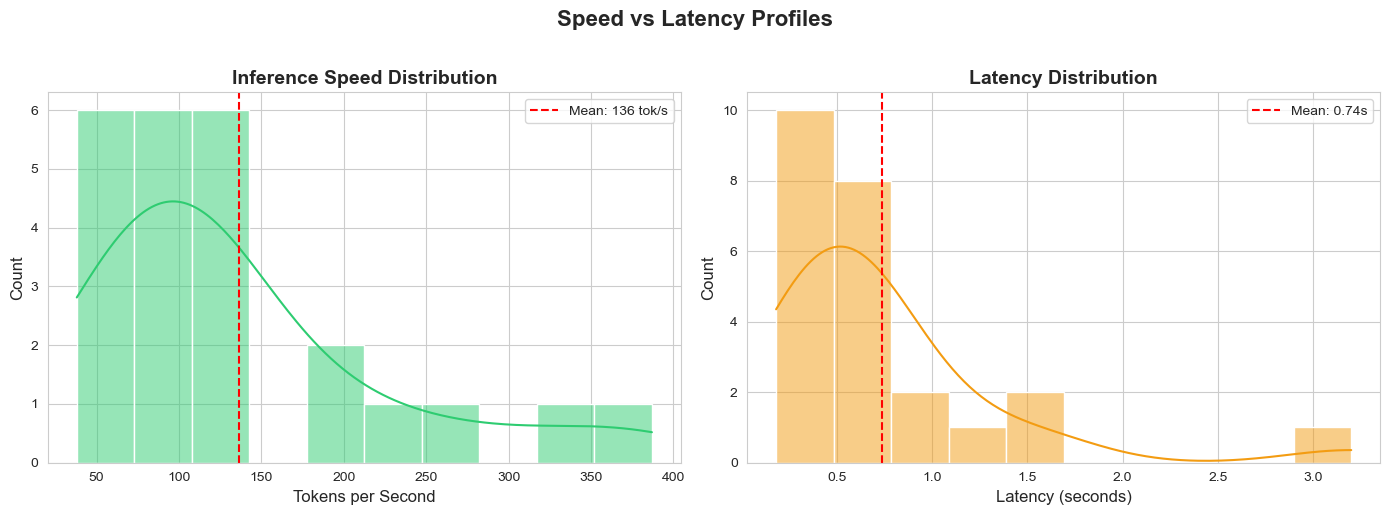

Speed & Latency Summary:
             count    mean    std    min    25%     50%     75%    max
speed_tok_s   24.0  136.17  91.83  38.00  84.00  107.50  152.75  387.0
latency_s     24.0    0.74   0.64   0.18   0.39    0.56    0.75    3.2


In [ ]:
# 9. SPEED & LATENCY ANALYSIS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Speed distribution
sns.histplot(df_clean['speed_tok_s'], kde=True, bins=10, color='#2ecc71', ax=axes[0])
axes[0].axvline(df_clean['speed_tok_s'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["speed_tok_s"].mean():.0f} tok/s')
axes[0].set_title('Inference Speed Distribution', fontweight='bold')
axes[0].set_xlabel('Tokens per Second')
axes[0].legend()

# Latency distribution
sns.histplot(df_clean['latency_s'], kde=True, bins=10, color='#f39c12', ax=axes[1])
axes[1].axvline(df_clean['latency_s'].mean(), color='red', linestyle='--', label=f'Mean: {df_clean["latency_s"].mean():.2f}s')
axes[1].set_title('Latency Distribution', fontweight='bold')
axes[1].set_xlabel('Latency (seconds)')
axes[1].legend()

plt.suptitle('Speed vs Latency Profiles', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Speed & Latency Summary:")
print(df_clean[['speed_tok_s', 'latency_s']].describe().round(2).T)


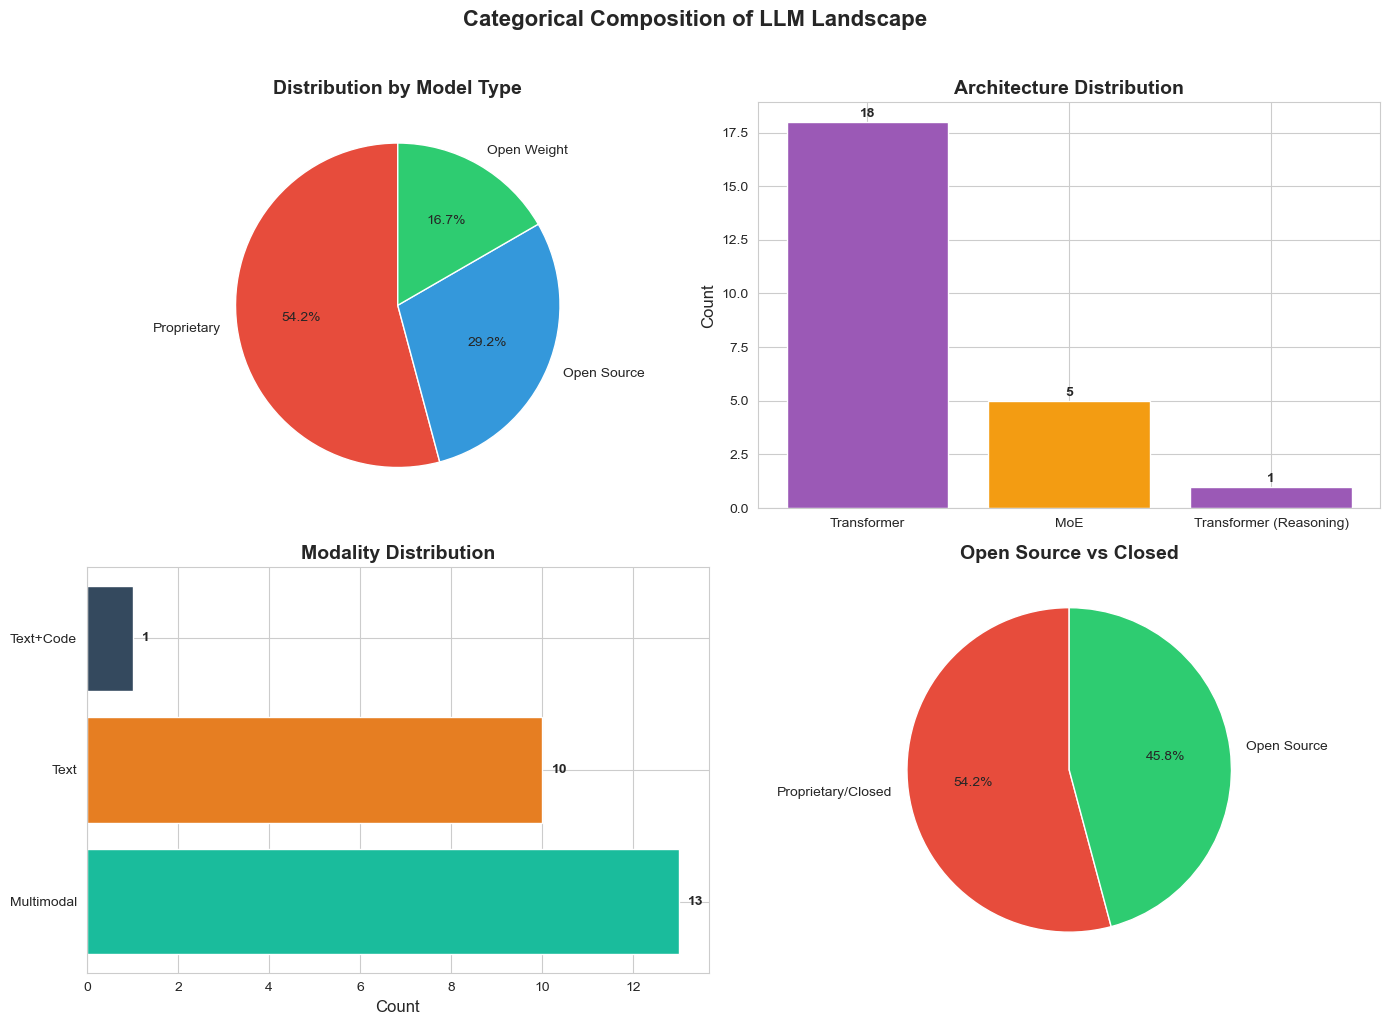

In [ ]:
# 10. CATEGORICAL ANALYSIS — TYPE, ARCHITECTURE, MODALITY
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Model Type
type_counts = df_clean['type'].value_counts()
axes[0,0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', 
              colors=['#e74c3c', '#3498db', '#2ecc71'], startangle=90)
axes[0,0].set_title('Distribution by Model Type', fontweight='bold')

# Architecture
arch_counts = df_clean['architecture'].value_counts()
axes[0,1].bar(arch_counts.index, arch_counts.values, color=['#9b59b6', '#f39c12'])
axes[0,1].set_title('Architecture Distribution', fontweight='bold')
axes[0,1].set_ylabel('Count')
for i, v in enumerate(arch_counts.values):
    axes[0,1].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# Modality
mod_counts = df_clean['modality'].value_counts()
axes[1,0].barh(mod_counts.index, mod_counts.values, color=['#1abc9c', '#e67e22', '#34495e'])
axes[1,0].set_title('Modality Distribution', fontweight='bold')
axes[1,0].set_xlabel('Count')
for i, v in enumerate(mod_counts.values):
    axes[1,0].text(v + 0.2, i, str(v), va='center', fontweight='bold')

# Open Source vs Proprietary
os_counts = df_clean['open_source'].value_counts()
labels = ['Proprietary/Closed', 'Open Source']
axes[1,1].pie(os_counts.values, labels=labels, autopct='%1.1f%%', 
              colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1,1].set_title('Open Source vs Closed', fontweight='bold')

plt.suptitle('Categorical Composition of LLM Landscape', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


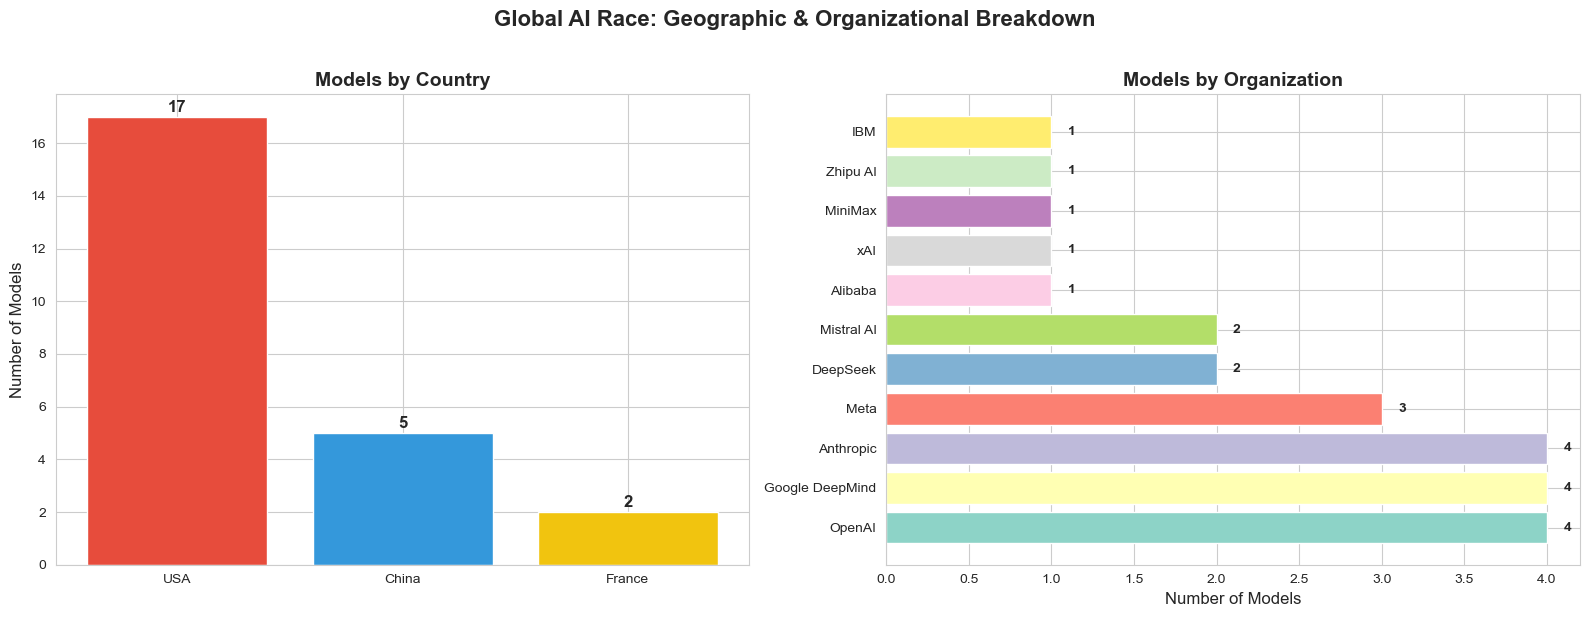

Country breakdown:
country
USA       17
China      5
France     2
Name: count, dtype: int64

Organization breakdown:
organization
OpenAI             4
Google DeepMind    4
Anthropic          4
Meta               3
DeepSeek           2
Mistral AI         2
Alibaba            1
xAI                1
MiniMax            1
Zhipu AI           1
IBM                1
Name: count, dtype: int64


In [ ]:
# 11. GEOGRAPHIC & ORGANIZATIONAL LANDSCAPE

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Country distribution
country_counts = df_clean['country'].value_counts()
colors_country = ['#e74c3c', '#3498db', '#f1c40f', '#2ecc71', '#9b59b6'][:len(country_counts)]
axes[0].bar(country_counts.index, country_counts.values, color=colors_country)
axes[0].set_title('Models by Country', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Number of Models')
for i, v in enumerate(country_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold', fontsize=12)

# Organization distribution
org_counts = df_clean['organization'].value_counts()
axes[1].barh(org_counts.index, org_counts.values, color=plt.cm.Set3(np.linspace(0, 1, len(org_counts))))
axes[1].set_title('Models by Organization', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Number of Models')
for i, v in enumerate(org_counts.values):
    axes[1].text(v + 0.1, i, str(v), va='center', fontweight='bold')

plt.suptitle('Global AI Race: Geographic & Organizational Breakdown', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Country breakdown:")
print(country_counts)
print("\nOrganization breakdown:")
print(org_counts)


## 🔗 PART B: BIVARIATE & MULTIVARIATE ANALYSIS

Exploring relationships between variables to uncover insights about performance, pricing, and strategy.

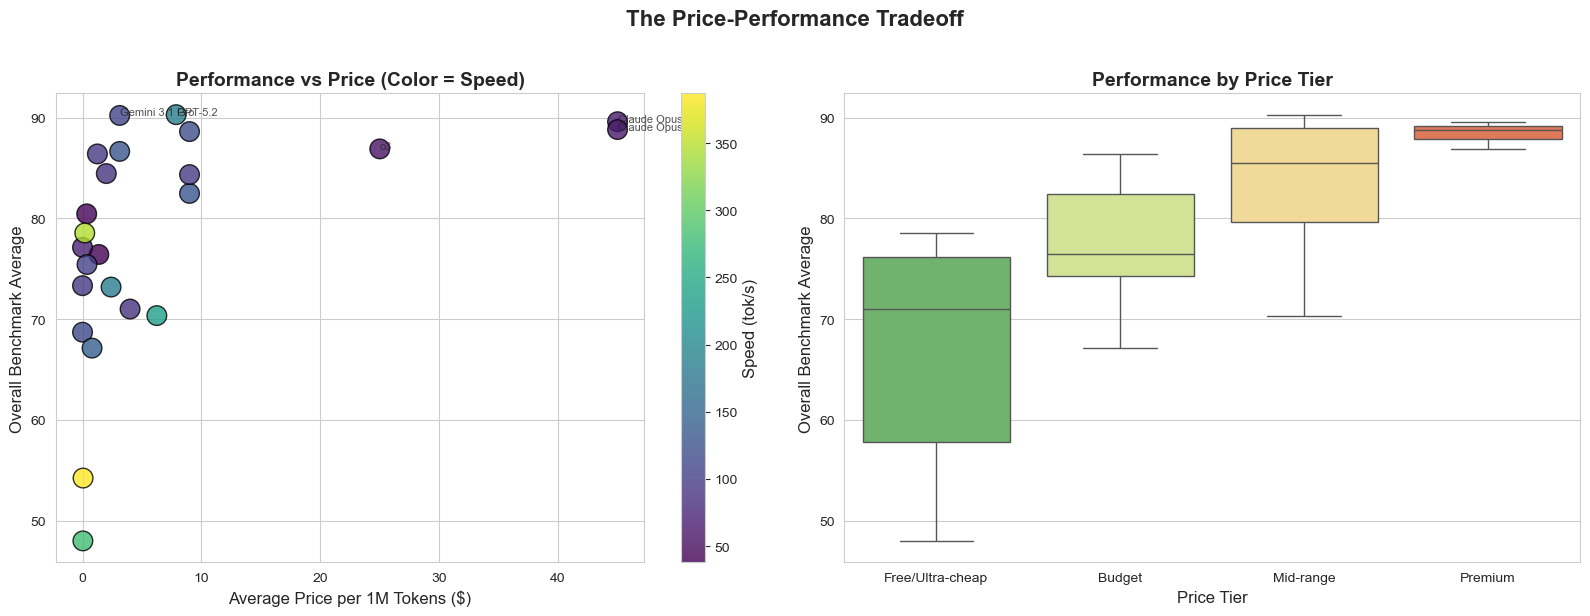

Correlation between Price and Performance: 0.459


In [ ]:
# 12. PERFORMANCE vs PRICE TRADEOFF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Overall Benchmark vs Avg Price
scatter = axes[0].scatter(df_clean['avg_price_per_1m'], df_clean['overall_benchmark_avg'], 
                          c=df_clean['speed_tok_s'], s=200, cmap='viridis', alpha=0.8, edgecolors='black')
axes[0].set_xlabel('Average Price per 1M Tokens ($)')
axes[0].set_ylabel('Overall Benchmark Average')
axes[0].set_title('Performance vs Price (Color = Speed)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Speed (tok/s)')

# Annotate outliers
for idx, row in df_clean.iterrows():
    if row['avg_price_per_1m'] > 20 or row['overall_benchmark_avg'] > 89:
        axes[0].annotate(row['model_name'], (row['avg_price_per_1m'], row['overall_benchmark_avg']), 
                        fontsize=8, alpha=0.8)

# Boxplot: Performance by Price Tier
sns.boxplot(x='price_tier', y='overall_benchmark_avg', data=df_clean, 
            order=['Free/Ultra-cheap', 'Budget', 'Mid-range', 'Premium'], palette='RdYlGn_r', ax=axes[1])
axes[1].set_title('Performance by Price Tier', fontweight='bold')
axes[1].set_xlabel('Price Tier')
axes[1].set_ylabel('Overall Benchmark Average')

plt.suptitle('The Price-Performance Tradeoff', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Correlation
corr_price_perf = df_clean[['avg_price_per_1m', 'overall_benchmark_avg']].corr().iloc[0,1]
print(f"Correlation between Price and Performance: {corr_price_perf:.3f}")


In [ ]:
# 13. BEST PERFORMANCE PER DOLLAR
fig, ax = plt.subplots(figsize=(14, 8))

# Sort by performance_per_dollar
df_sorted = df_clean.sort_values('performance_per_dollar', ascending=True)
colors = ['#2ecc71' if t == 'Open Source' else '#3498db' if t == 'Open Weight' else '#e74c3c' 
          for t in df_sorted['type']]

bars = ax.barh(df_sorted['model_name'], df_sorted['performance_per_dollar'], color=colors, edgecolor='black')
ax.set_xlabel('Performance per Dollar (Benchmark points / $ per 1M tokens)')
ax.set_title('Best Bang for Buck: Performance per Dollar', fontweight='bold', fontsize=14)
ax.set_xlim(0, df_sorted['performance_per_dollar'].max() * 1.1)

# Add value labels
for bar, val in zip(bars, df_sorted['performance_per_dollar']):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:.1f}', 
            va='center', fontweight='bold', fontsize=9)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Open Source'),
                   Patch(facecolor='#3498db', label='Open Weight'),
                   Patch(facecolor='#e74c3c', label='Proprietary')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("TOP 5 Best Performance per Dollar:")
print(df_clean[['model_name', 'type', 'overall_benchmark_avg', 'avg_price_per_1m', 'performance_per_dollar']]
      .sort_values('performance_per_dollar', ascending=False).head().to_string(index=False))


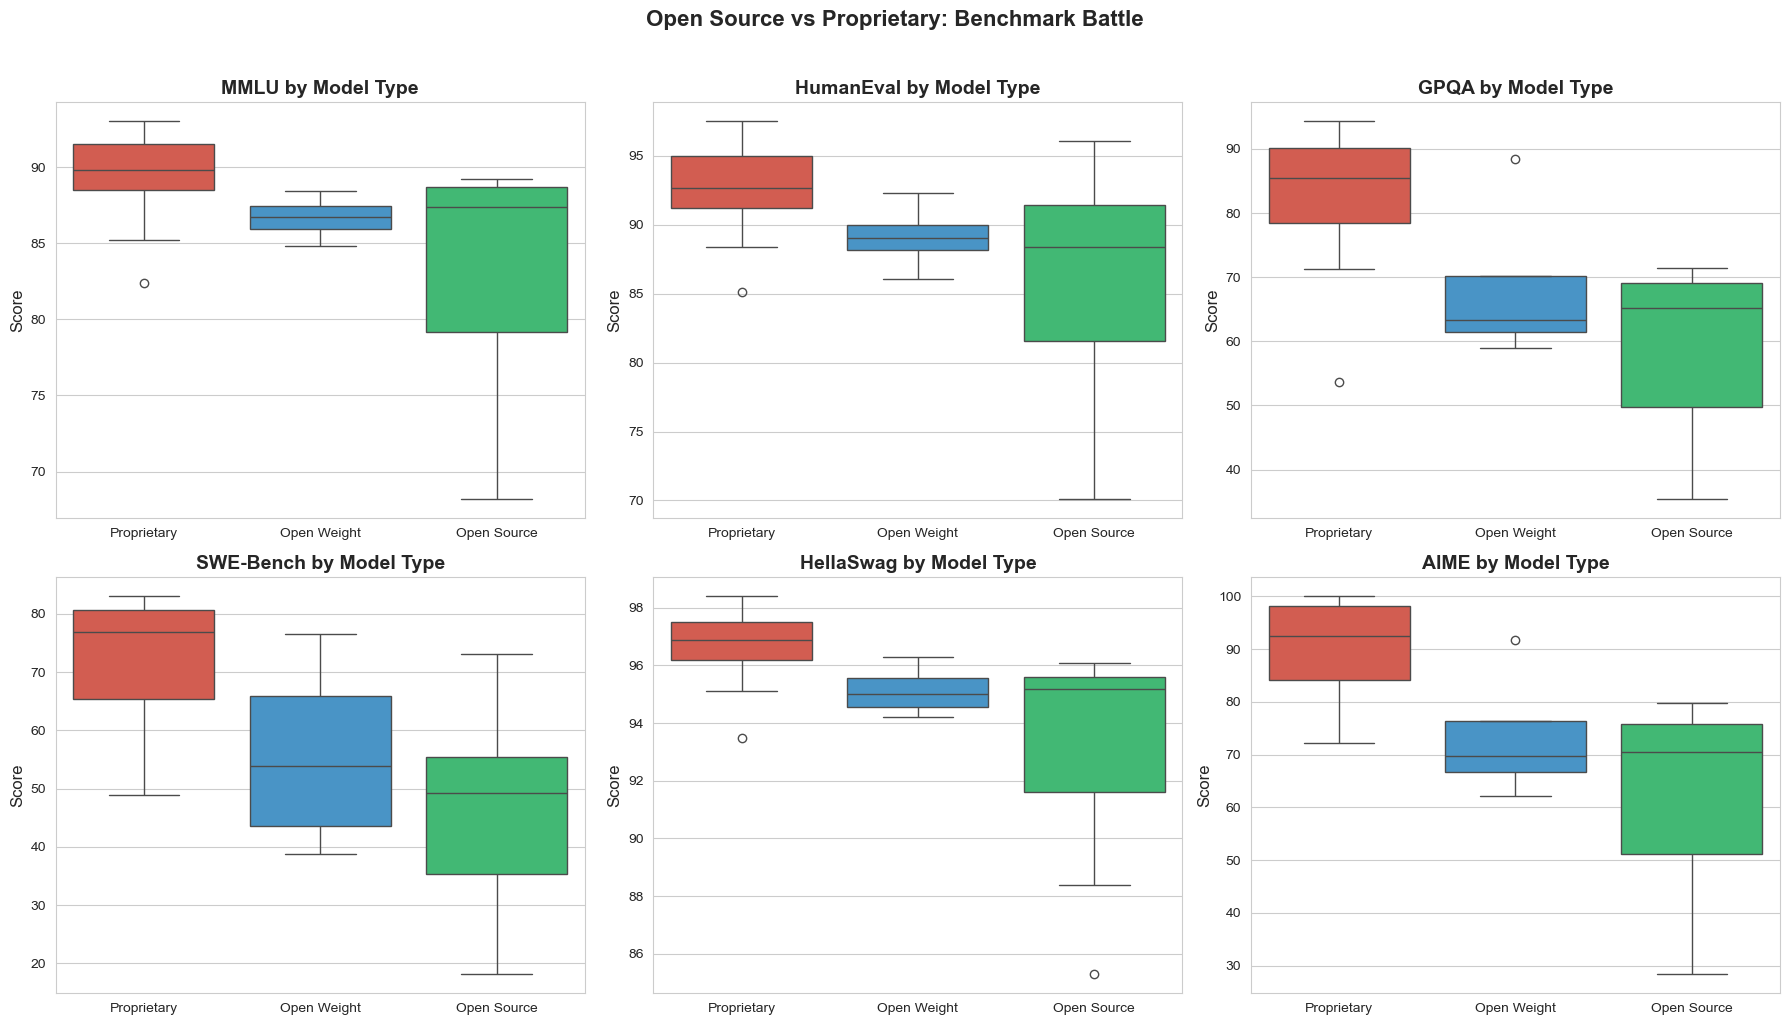

Mean Benchmark Scores by Model Type:
              mmlu  humaneval  gpqa_diamond  swe_bench  hellaswag  aime_2025  \
type                                                                           
Open Source  82.94      85.81         58.54      45.97      93.00      61.76   
Open Weight  86.65      89.12         68.45      55.72      95.12      73.35   
Proprietary  89.48      92.54         82.69      72.05      96.65      89.93   

             overall_benchmark_avg  
type                                
Open Source                  68.32  
Open Weight                  74.98  
Proprietary                  84.19  

Gap Analysis (Proprietary - Open Source):
mmlu                      6.54
humaneval                 6.73
gpqa_diamond             24.15
swe_bench                26.08
hellaswag                 3.65
aime_2025                28.17
overall_benchmark_avg    15.87
dtype: float64


In [ ]:
# 14. OPEN SOURCE vs PROPRIETARY COMPARISON

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics = ['mmlu', 'humaneval', 'gpqa_diamond', 'swe_bench', 'hellaswag', 'aime_2025']
metric_names = ['MMLU', 'HumanEval', 'GPQA', 'SWE-Bench', 'HellaSwag', 'AIME']

for i, (metric, name) in enumerate(zip(metrics, metric_names)):
    sns.boxplot(x='type', y=metric, data=df_clean, 
                palette={'Open Source': '#2ecc71', 'Open Weight': '#3498db', 'Proprietary': '#e74c3c'},
                ax=axes[i])
    axes[i].set_title(f'{name} by Model Type', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Score')

plt.suptitle('Open Source vs Proprietary: Benchmark Battle', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Statistical comparison
print("Mean Benchmark Scores by Model Type:")
comparison = df_clean.groupby('type')[metrics + ['overall_benchmark_avg']].mean().round(2)
print(comparison)

print("\nGap Analysis (Proprietary - Open Source):")
if 'Open Source' in comparison.index and 'Proprietary' in comparison.index:
    gap = comparison.loc['Proprietary'] - comparison.loc['Open Source']
    print(gap.round(2))


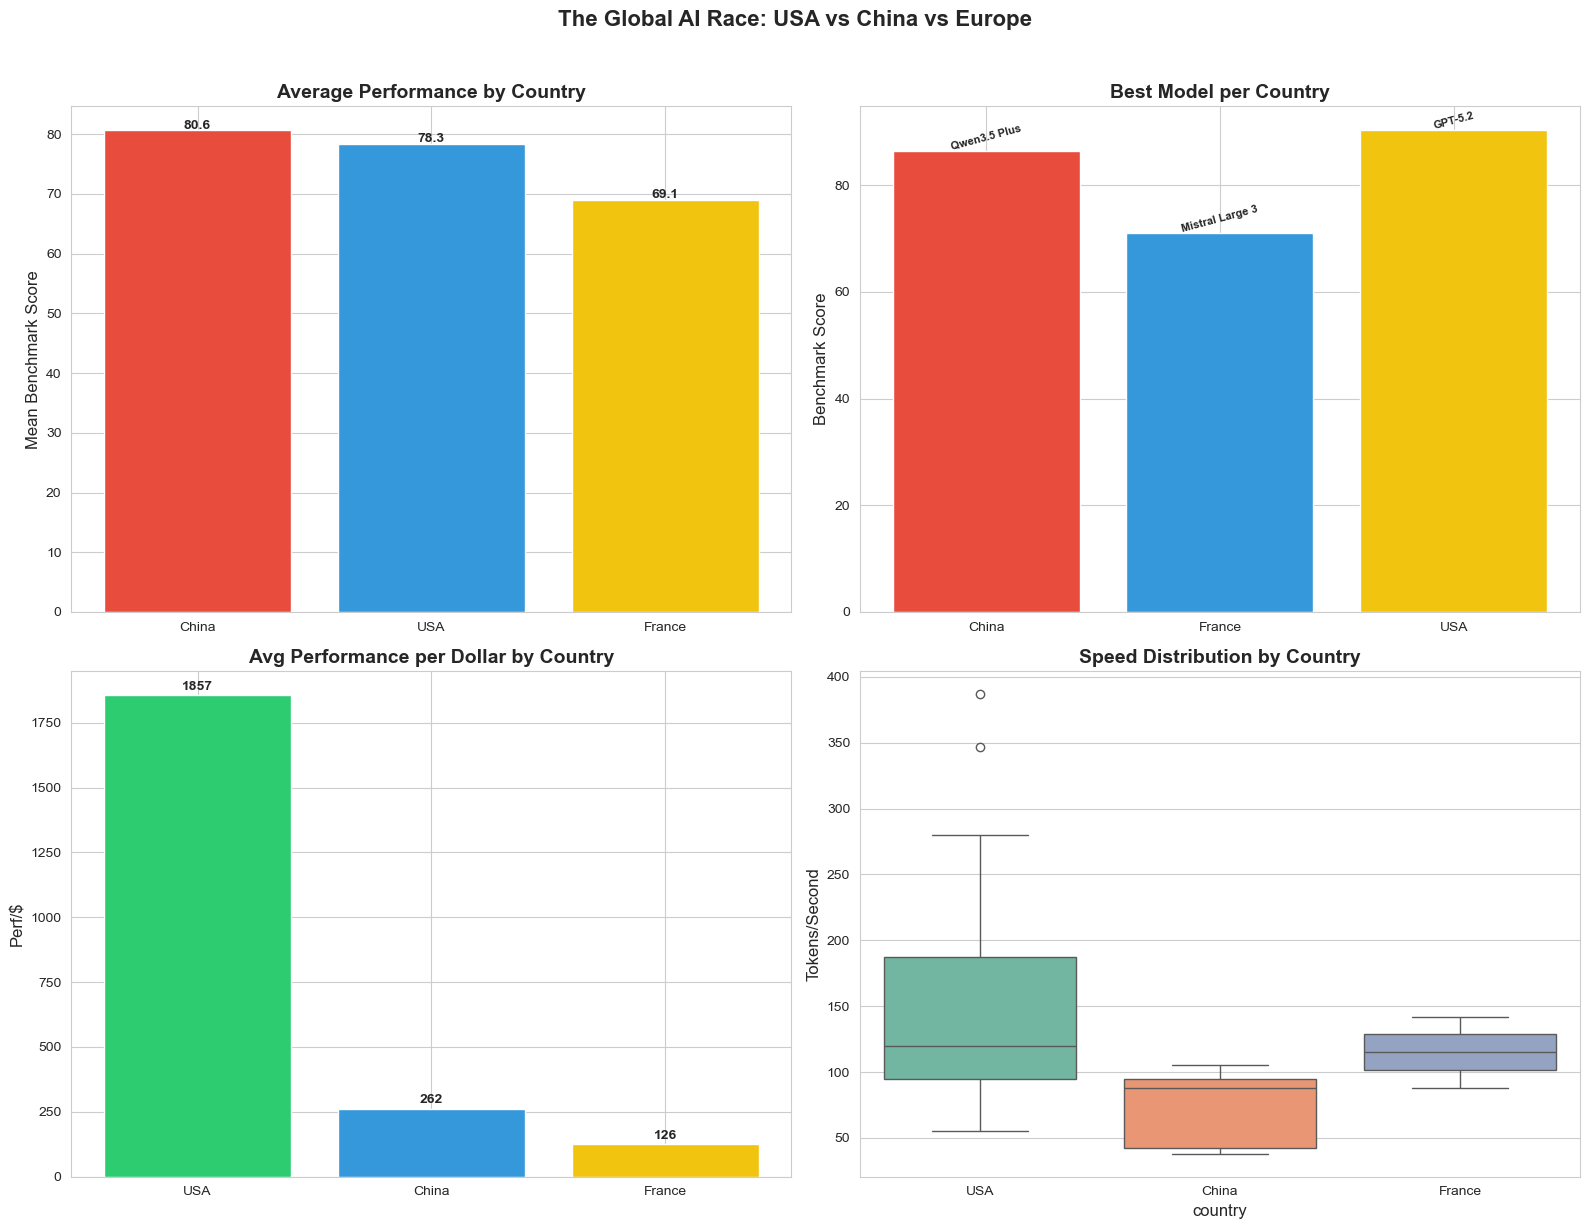

Country Leaderboard:
          mean   max  count
country                    
China    80.63  86.4      5
USA      78.32  90.3     17
France   69.06  71.0      2


In [ ]:

# 15. COUNTRY COMPARISON — THE AI RACE

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall performance by country
country_perf = df_clean.groupby('country')['overall_benchmark_avg'].agg(['mean', 'max', 'count']).round(2)
country_perf = country_perf.sort_values('mean', ascending=False)

axes[0,0].bar(country_perf.index, country_perf['mean'], color=['#e74c3c', '#3498db', '#f1c40f', '#2ecc71', '#9b59b6'][:len(country_perf)])
axes[0,0].set_title('Average Performance by Country', fontweight='bold')
axes[0,0].set_ylabel('Mean Benchmark Score')
for i, v in enumerate(country_perf['mean']):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Best model per country
best_per_country = df_clean.loc[df_clean.groupby('country')['overall_benchmark_avg'].idxmax()]
axes[0,1].bar(best_per_country['country'], best_per_country['overall_benchmark_avg'], 
              color=['#e74c3c', '#3498db', '#f1c40f', '#2ecc71', '#9b59b6'][:len(best_per_country)])
axes[0,1].set_title('Best Model per Country', fontweight='bold')
axes[0,1].set_ylabel('Benchmark Score')
for i, (idx, row) in enumerate(best_per_country.iterrows()):
    axes[0,1].text(i, row['overall_benchmark_avg'] + 0.3, row['model_name'], 
                   ha='center', fontweight='bold', fontsize=8, rotation=15)

# Price efficiency by country
country_eff = df_clean.groupby('country')['performance_per_dollar'].mean().sort_values(ascending=False)
axes[1,0].bar(country_eff.index, country_eff.values, color=['#2ecc71', '#3498db', '#f1c40f', '#e74c3c', '#9b59b6'][:len(country_eff)])
axes[1,0].set_title('Avg Performance per Dollar by Country', fontweight='bold')
axes[1,0].set_ylabel('Perf/$')
for i, v in enumerate(country_eff.values):
    axes[1,0].text(i, v + 20, f'{v:.0f}', ha='center', fontweight='bold')

# Speed by country
sns.boxplot(x='country', y='speed_tok_s', data=df_clean, palette='Set2', ax=axes[1,1])
axes[1,1].set_title('Speed Distribution by Country', fontweight='bold')
axes[1,1].set_ylabel('Tokens/Second')

plt.suptitle('The Global AI Race: USA vs China vs Europe', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Country Leaderboard:")
print(country_perf)


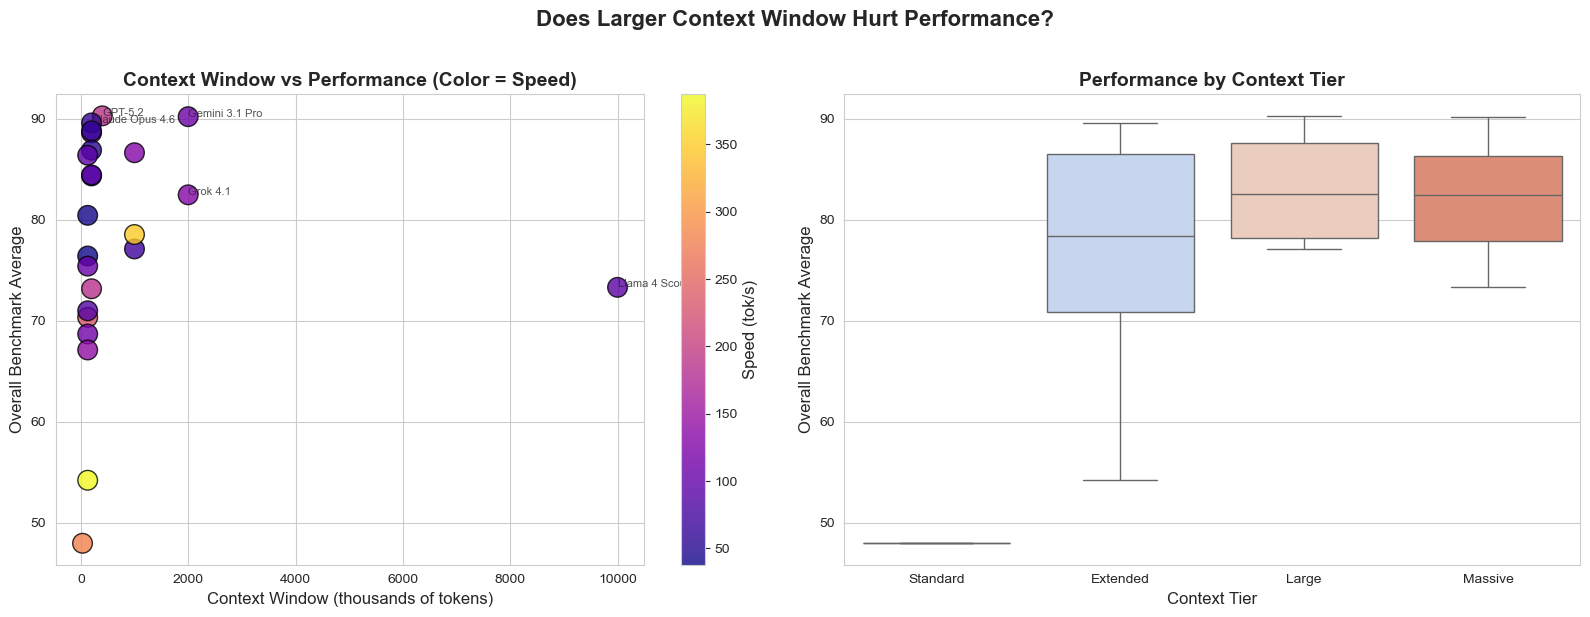

Correlation (Context Window <-> Performance): 0.003

Performance by Context Tier:
               mean  median    std
context_tier                      
Extended      77.88   78.44  10.04
Large         83.16   82.60   6.35
Massive       82.01   82.48   8.46
Standard      47.98   47.98    NaN


In [ ]:
# 16. CONTEXT WINDOW vs PERFORMANCE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Context vs Performance
scatter = axes[0].scatter(df_clean['context_window_k'], df_clean['overall_benchmark_avg'], 
                          c=df_clean['speed_tok_s'], s=200, cmap='plasma', alpha=0.8, edgecolors='black')
axes[0].set_xlabel('Context Window (thousands of tokens)')
axes[0].set_ylabel('Overall Benchmark Average')
axes[0].set_title('Context Window vs Performance (Color = Speed)', fontweight='bold')
plt.colorbar(scatter, ax=axes[0], label='Speed (tok/s)')

# Annotate extreme context models
for idx, row in df_clean.iterrows():
    if row['context_window_k'] > 1000 or row['overall_benchmark_avg'] > 89:
        axes[0].annotate(row['model_name'], (row['context_window_k'], row['overall_benchmark_avg']), 
                        fontsize=8, alpha=0.8)

# Context tier vs performance
sns.boxplot(x='context_tier', y='overall_benchmark_avg', data=df_clean, 
            order=['Standard', 'Extended', 'Large', 'Massive'], palette='coolwarm', ax=axes[1])
axes[1].set_title('Performance by Context Tier', fontweight='bold')
axes[1].set_xlabel('Context Tier')
axes[1].set_ylabel('Overall Benchmark Average')

plt.suptitle('Does Larger Context Window Hurt Performance?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Correlation
corr_context = df_clean[['context_window_k', 'overall_benchmark_avg']].corr().iloc[0,1]
print(f"Correlation (Context Window <-> Performance): {corr_context:.3f}")

print("\nPerformance by Context Tier:")
print(df_clean.groupby('context_tier')['overall_benchmark_avg'].agg(['mean', 'median', 'std']).round(2))


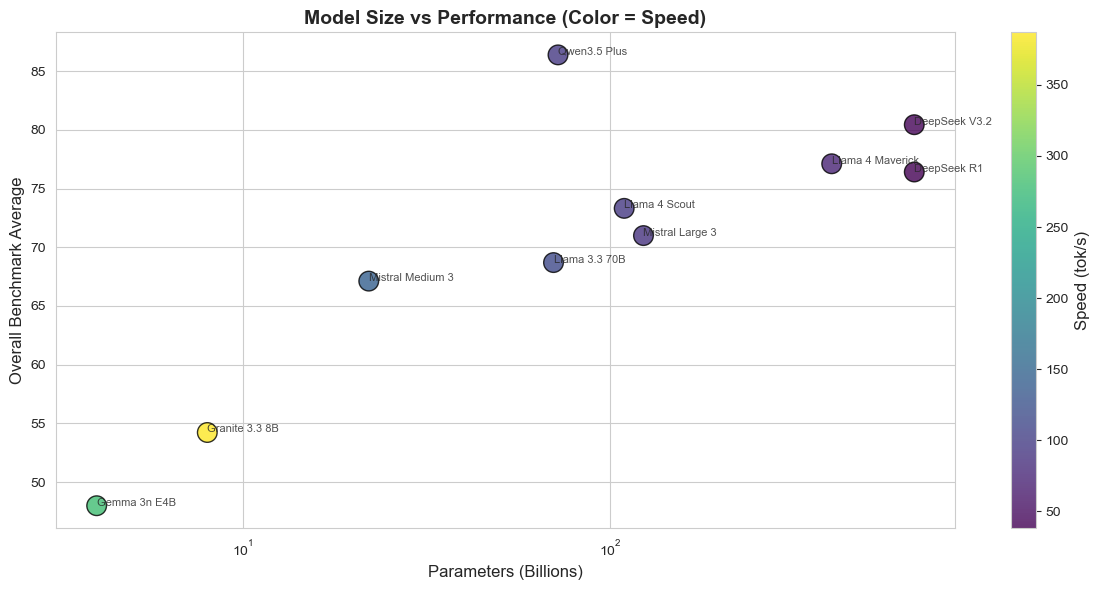

Correlation (Parameters <-> Performance): 0.533 (log-scale may improve)
Disclosed parameters range: 4B to 671B


In [ ]:

# 17. MODEL SIZE (PARAMETERS) vs PERFORMANCE
# Filter only models with disclosed parameters
df_disclosed = df_clean[df_clean['parameters_b'] > 0].copy()

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(df_disclosed['parameters_b'], df_disclosed['overall_benchmark_avg'], 
                     c=df_disclosed['speed_tok_s'], s=200, cmap='viridis', alpha=0.8, edgecolors='black')
ax.set_xlabel('Parameters (Billions)')
ax.set_ylabel('Overall Benchmark Average')
ax.set_title('Model Size vs Performance (Color = Speed)', fontweight='bold')
ax.set_xscale('log')
plt.colorbar(scatter, ax=ax, label='Speed (tok/s)')

for idx, row in df_disclosed.iterrows():
    ax.annotate(row['model_name'], (row['parameters_b'], row['overall_benchmark_avg']), 
                fontsize=8, alpha=0.8)

plt.tight_layout()
plt.show()

corr_size = df_disclosed[['parameters_b', 'overall_benchmark_avg']].corr().iloc[0,1]
print(f"Correlation (Parameters <-> Performance): {corr_size:.3f} (log-scale may improve)")
print(f"Disclosed parameters range: {df_disclosed['parameters_b'].min():.0f}B to {df_disclosed['parameters_b'].max():.0f}B")


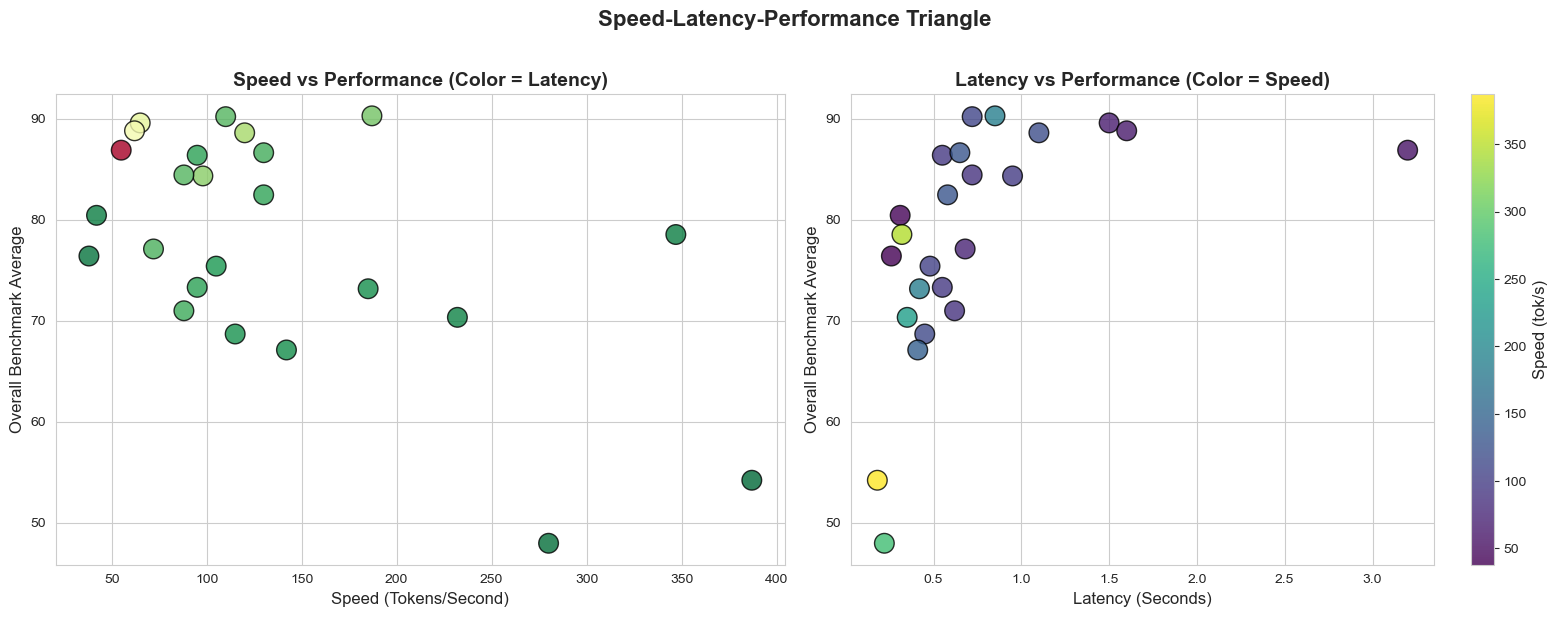

Correlations:
   Speed <-> Performance: -0.581
   Latency <-> Performance: 0.520
   Speed <-> Latency: -0.411


In [ ]:

# 18. SPEED vs PERFORMANCE & LATENCY

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Speed vs Performance
axes[0].scatter(df_clean['speed_tok_s'], df_clean['overall_benchmark_avg'], 
                c=df_clean['latency_s'], s=200, cmap='RdYlGn_r', alpha=0.8, edgecolors='black')
axes[0].set_xlabel('Speed (Tokens/Second)')
axes[0].set_ylabel('Overall Benchmark Average')
axes[0].set_title('Speed vs Performance (Color = Latency)', fontweight='bold')

# Latency vs Performance
scatter = axes[1].scatter(df_clean['latency_s'], df_clean['overall_benchmark_avg'], 
                          c=df_clean['speed_tok_s'], s=200, cmap='viridis', alpha=0.8, edgecolors='black')
axes[1].set_xlabel('Latency (Seconds)')
axes[1].set_ylabel('Overall Benchmark Average')
axes[1].set_title('Latency vs Performance (Color = Speed)', fontweight='bold')
plt.colorbar(scatter, ax=axes[1], label='Speed (tok/s)')

plt.suptitle('Speed-Latency-Performance Triangle', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Correlations:")
print(f"   Speed <-> Performance: {df_clean[['speed_tok_s', 'overall_benchmark_avg']].corr().iloc[0,1]:.3f}")
print(f"   Latency <-> Performance: {df_clean[['latency_s', 'overall_benchmark_avg']].corr().iloc[0,1]:.3f}")
print(f"   Speed <-> Latency: {df_clean[['speed_tok_s', 'latency_s']].corr().iloc[0,1]:.3f}")


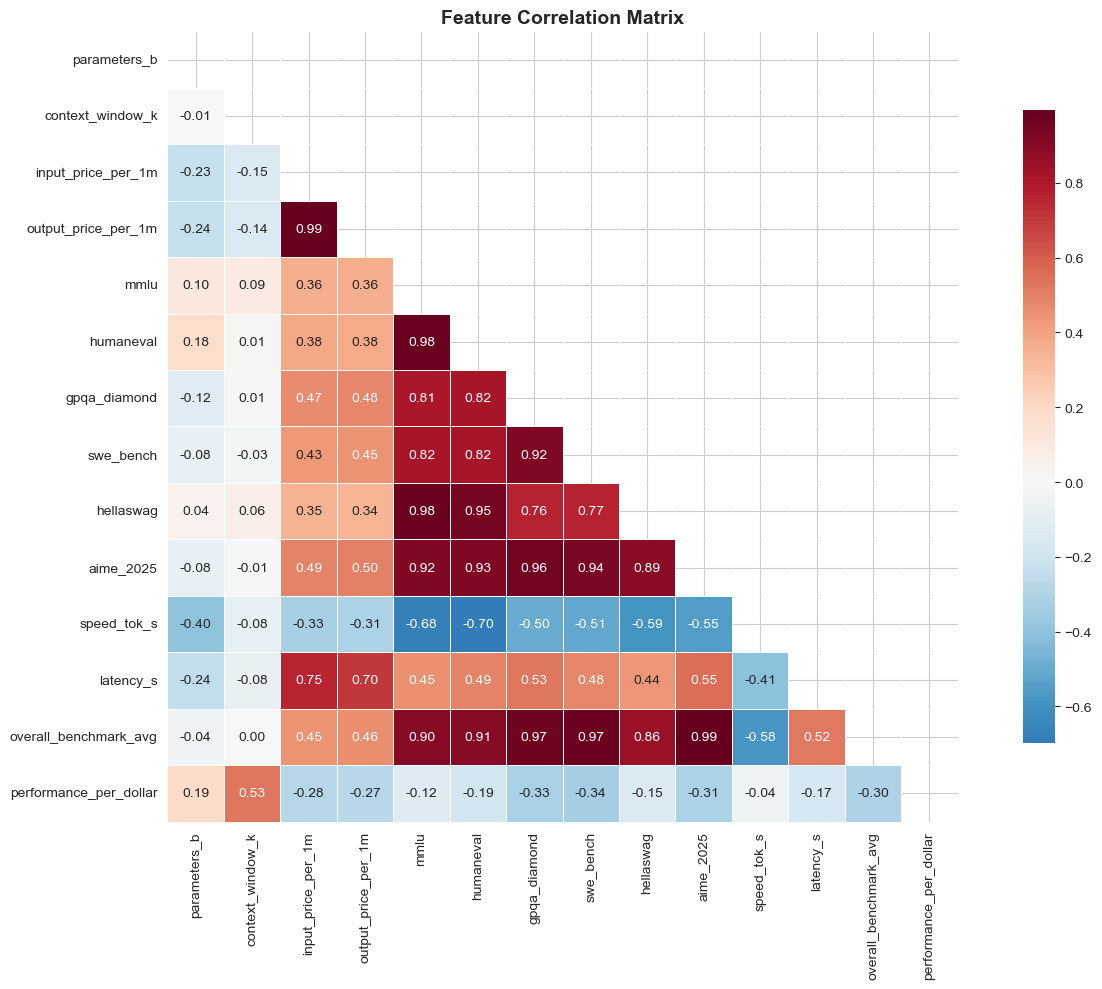

Strongest Positive Correlations with Overall Benchmark:
aime_2025       0.987
swe_bench       0.971
gpqa_diamond    0.967
humaneval       0.906
mmlu            0.902
hellaswag       0.857
Name: overall_benchmark_avg, dtype: float64

Strongest Negative Correlations with Overall Benchmark:
parameters_b             -0.037
performance_per_dollar   -0.302
speed_tok_s              -0.581
Name: overall_benchmark_avg, dtype: float64


In [ ]:

# 19. CORRELATION HEATMAP

fig, ax = plt.subplots(figsize=(14, 10))

# Select numeric columns for correlation
numeric_features = ['parameters_b', 'context_window_k', 'input_price_per_1m', 'output_price_per_1m',
                    'mmlu', 'humaneval', 'gpqa_diamond', 'swe_bench', 'hellaswag', 'aime_2025',
                    'speed_tok_s', 'latency_s', 'overall_benchmark_avg', 'performance_per_dollar']

corr_matrix = df_clean[numeric_features].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

print("Strongest Positive Correlations with Overall Benchmark:")
perf_corr = corr_matrix['overall_benchmark_avg'].drop('overall_benchmark_avg').sort_values(ascending=False)
print(perf_corr.head(6).round(3))

print("\nStrongest Negative Correlations with Overall Benchmark:")
print(perf_corr.tail(3).round(3))


## 🤖 PART C: PREDICTIVE & ADVANCED ANALYSIS

Using simple ML techniques to answer deeper questions.

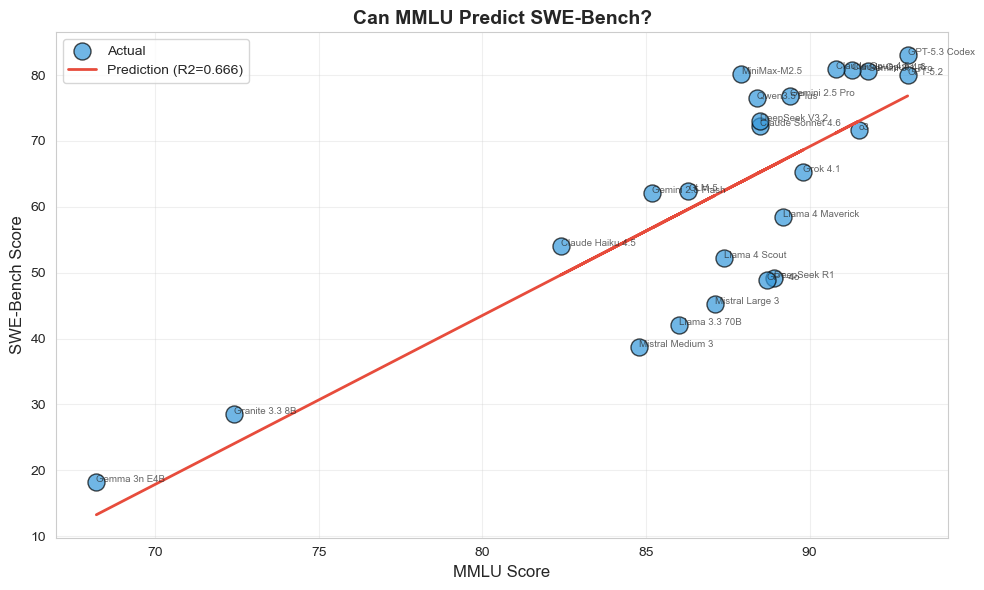

Regression Results:
   R2 Score: 0.666 (66.6% variance explained)
   RMSE: 10.34 points
   Equation: SWE-Bench = 2.56 * MMLU + -161.60
   MMLU is a reasonably good predictor of SWE-Bench


In [ ]:

# 20. PREDICT SWE-BENCH FROM MMLU (LINEAR REGRESSION)

X = df_clean[['mmlu']].values
y = df_clean['swe_bench'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X, y, s=150, color='#3498db', alpha=0.7, edgecolors='black', label='Actual')
ax.plot(X, y_pred, color='#e74c3c', linewidth=2, label=f'Prediction (R2={r2:.3f})')

for idx, row in df_clean.iterrows():
    ax.annotate(row['model_name'], (row['mmlu'], row['swe_bench']), fontsize=7, alpha=0.7)

ax.set_xlabel('MMLU Score')
ax.set_ylabel('SWE-Bench Score')
ax.set_title('Can MMLU Predict SWE-Bench?', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Regression Results:")
print(f"   R2 Score: {r2:.3f} ({r2*100:.1f}% variance explained)")
print(f"   RMSE: {rmse:.2f} points")
print(f"   Equation: SWE-Bench = {model.coef_[0]:.2f} * MMLU + {model.intercept_:.2f}")

if r2 > 0.5:
    print("   MMLU is a reasonably good predictor of SWE-Bench")
else:
    print("   MMLU alone is NOT a strong predictor — coding ability differs from general knowledge")


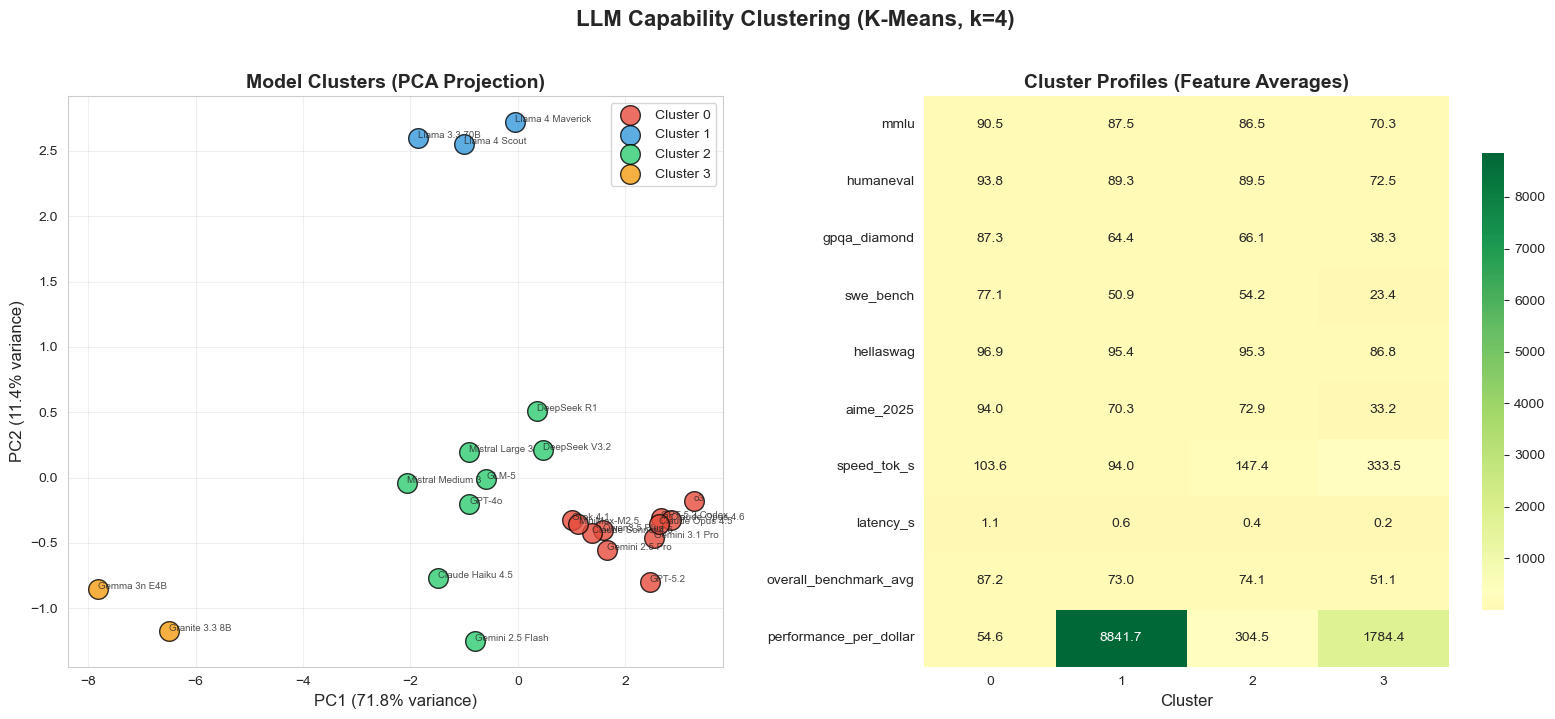

Cluster Sizes:
   Cluster 0: 11 models
   Cluster 1: 3 models
   Cluster 2: 8 models
   Cluster 3: 2 models

Cluster Characteristics:
          mmlu  humaneval  gpqa_diamond  swe_bench  hellaswag  aime_2025  \
cluster                                                                    
0        90.49      93.78         87.28      77.10      96.89      94.05   
1        87.53      89.30         64.43      50.93      95.37      70.30   
2        86.49      89.48         66.08      54.21      95.30      72.86   
3        70.30      72.45         38.30      23.35      86.85      33.25   

         speed_tok_s  latency_s  overall_benchmark_avg  performance_per_dollar  
cluster                                                                         
0             103.64       1.13                  87.16                   54.60  
1              94.00       0.56                  73.05                 8841.67  
2             147.38       0.40                  74.06                  304.50  
3   

In [ ]:
# 21. CLUSTERING MODELS BY CAPABILITY PROFILE

# Features for clustering
cluster_features = ['mmlu', 'humaneval', 'gpqa_diamond', 'swe_bench', 'hellaswag', 'aime_2025',
                    'speed_tok_s', 'latency_s', 'overall_benchmark_avg', 'performance_per_dollar']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[cluster_features])

# K-Means with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA for 2D visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
for i in range(4):
    mask = df_clean['cluster'] == i
    cluster_indices = df_clean[mask].index.tolist()
    pca_mask = [idx in cluster_indices for idx in df_clean.index]
    pca_x = X_pca[pca_mask, 0]
    pca_y = X_pca[pca_mask, 1]
    axes[0].scatter(pca_x, pca_y, c=colors[i], s=200, alpha=0.8, 
                    edgecolors='black', label=f'Cluster {i}')
    for j, idx in enumerate(cluster_indices):
        axes[0].annotate(df_clean.loc[idx, 'model_name'], 
                        (pca_x[j], pca_y[j]),
                        fontsize=7, alpha=0.8)

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('Model Clusters (PCA Projection)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cluster characteristics
cluster_summary = df_clean.groupby('cluster')[cluster_features].mean().round(2)
cluster_size = df_clean['cluster'].value_counts().sort_index()

# Heatmap of cluster centers
sns.heatmap(cluster_summary.T, annot=True, fmt='.1f', cmap='RdYlGn', center=cluster_summary.values.mean(),
            ax=axes[1], cbar_kws={"shrink": 0.8})
axes[1].set_title('Cluster Profiles (Feature Averages)', fontweight='bold')
axes[1].set_xlabel('Cluster')

plt.suptitle('LLM Capability Clustering (K-Means, k=4)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Cluster Sizes:")
for i, size in enumerate(cluster_size):
    print(f"   Cluster {i}: {size} models")

print("\nCluster Characteristics:")
print(cluster_summary)


In [ ]:

# 22. CLUSTER INTERPRETATION
print("MODELS IN EACH CLUSTER:\n")
for i in sorted(df_clean['cluster'].unique()):
    cluster_models = df_clean[df_clean['cluster'] == i][['model_name', 'organization', 'type', 'overall_benchmark_avg', 'performance_per_dollar']]
    print("-" * 60)
    print(f"CLUSTER {i} ({len(cluster_models)} models):")
    print(cluster_models.to_string(index=False))
    print()

# Auto-label clusters based on characteristics
cluster_labels = {}
for i in sorted(df_clean['cluster'].unique()):
    avg_perf = df_clean[df_clean['cluster'] == i]['overall_benchmark_avg'].mean()
    avg_eff = df_clean[df_clean['cluster'] == i]['performance_per_dollar'].mean()
    avg_speed = df_clean[df_clean['cluster'] == i]['speed_tok_s'].mean()

    if avg_perf > 85:
        label = "Elite Performers"
    elif avg_eff > 500:
        label = "Value Champions"
    elif avg_speed > 200:
        label = "Speed Demons"
    else:
        label = "Balanced / Niche"
    cluster_labels[i] = label

print("\nCLUSTER LABELS:")
for i, label in cluster_labels.items():
    print(f"   Cluster {i}: {label}")


MODELS IN EACH CLUSTER:

------------------------------------------------------------
CLUSTER 0 (11 models):
       model_name    organization        type  overall_benchmark_avg  performance_per_dollar
          GPT-5.2          OpenAI Proprietary                  90.30                   53.41
    GPT-5.3 Codex          OpenAI Proprietary                  88.62                   31.64
   Gemini 3.1 Pro Google DeepMind Proprietary                  90.22                   73.81
  Claude Opus 4.6       Anthropic Proprietary                  89.60                    6.21
  Claude Opus 4.5       Anthropic Proprietary                  88.82                    6.14
               o3          OpenAI Proprietary                  86.90                    9.40
     Qwen3.5 Plus         Alibaba Open Weight                  86.40                  177.16
         Grok 4.1             xAI Proprietary                  82.48                   30.32
   Gemini 2.5 Pro Google DeepMind Proprietary         

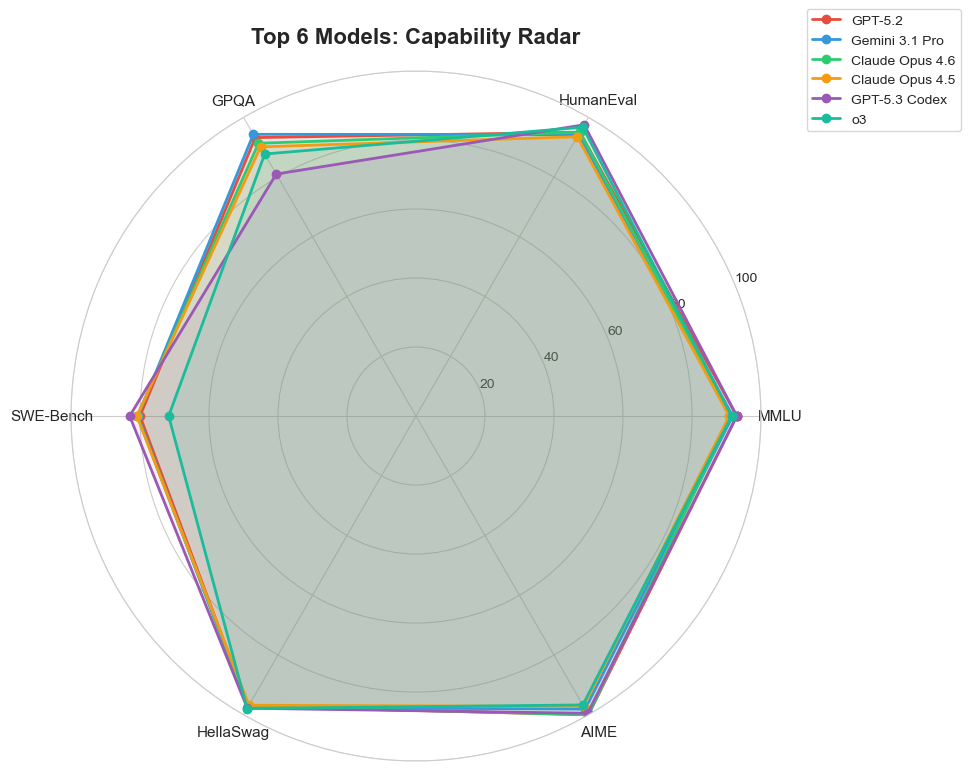

In [ ]:

# 23. RADAR CHART: TOP MODELS COMPARISON

from math import pi

# Select top 6 models by overall benchmark
top_models = df_clean.nlargest(6, 'overall_benchmark_avg')
categories = ['MMLU', 'HumanEval', 'GPQA', 'SWE-Bench', 'HellaSwag', 'AIME']
cat_cols = ['mmlu', 'humaneval', 'gpqa_diamond', 'swe_bench', 'hellaswag', 'aime_2025']

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

colors_radar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for idx, (i, row) in enumerate(top_models.iterrows()):
    values = [row[col] for col in cat_cols]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=row['model_name'], color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.1, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 100)
ax.set_title('Top 6 Models: Capability Radar', fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# 24. RELEASE TIMELINE ANALYSIS
df_clean['release_date'] = pd.to_datetime(df_clean[['release_year', 'release_month']].assign(day=1))

fig, ax = plt.subplots(figsize=(14, 8))

# Scatter timeline
for country in df_clean['country'].unique():
    country_data = df_clean[df_clean['country'] == country]
    ax.scatter(country_data['release_date'], country_data['overall_benchmark_avg'], 
               s=country_data['speed_tok_s']*2, alpha=0.7, label=country, edgecolors='black')
    for idx, row in country_data.iterrows():
        ax.annotate(row['model_name'], (row['release_date'], row['overall_benchmark_avg']), 
                    fontsize=8, alpha=0.8, rotation=15)

ax.set_xlabel('Release Date')
ax.set_ylabel('Overall Benchmark Average')
ax.set_title('LLM Release Timeline: Performance Evolution (Bubble Size = Speed)', fontweight='bold')
ax.legend(title='Country')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Release Timeline Summary:")
print(df_clean.groupby('release_year')['overall_benchmark_avg'].agg(['count', 'mean', 'max']).round(2))


## 📋 PART D: SUMMARY STATISTICS & KEY FINDINGS

In [ ]:
# 25. COMPREHENSIVE SUMMARY TABLE

summary_table = df_clean[['rank', 'model_name', 'organization', 'country', 'type', 
                          'overall_benchmark_avg', 'performance_per_dollar', 
                          'speed_tok_s', 'latency_s', 'context_window_k', 
                          'avg_price_per_1m', 'cluster']].copy()

summary_table.columns = ['Rank', 'Model', 'Org', 'Country', 'Type', 'Benchmark', 'Perf/$', 
                         'Speed', 'Latency', 'Context(K)', 'Avg Price', 'Cluster']

print("FULL MODEL RANKINGS:")
print(summary_table.sort_values('Rank').to_string(index=False))


FULL MODEL RANKINGS:
 Rank             Model             Org Country        Type  Benchmark  Perf/$  Speed  Latency  Context(K)  Avg Price  Cluster
    1           GPT-5.2          OpenAI     USA Proprietary      90.30   53.41    187     0.85         400     7.8750        0
    2     GPT-5.3 Codex          OpenAI     USA Proprietary      88.62   31.64    120     1.10         200     9.0000        0
    3    Gemini 3.1 Pro Google DeepMind     USA Proprietary      90.22   73.81    110     0.72        2000     3.1250        0
    4   Claude Opus 4.6       Anthropic     USA Proprietary      89.60    6.21     65     1.50         200    45.0000        0
    5   Claude Opus 4.5       Anthropic     USA Proprietary      88.82    6.14     62     1.60         200    45.0000        0
    6                o3          OpenAI     USA Proprietary      86.90    9.40     55     3.20         200    25.0000        0
    7      Qwen3.5 Plus         Alibaba   China Open Weight      86.40  177.16     95     

In [ ]:

# 26. KEY FINDINGS & INSIGHTS

print("=" * 70)
print("KEY FINDINGS FROM EDA")
print("=" * 70)

# Finding 1: Best value
best_value = df_clean.loc[df_clean['performance_per_dollar'].idxmax()]
print(f"\n1.  BEST VALUE FOR MONEY:")
print(f"   -> {best_value['model_name']} ({best_value['organization']})")
print(f"   -> Performance/$: {best_value['performance_per_dollar']:.1f}")
print(f"   -> Type: {best_value['type']} | Price: ${best_value['avg_price_per_1m']:.2f}/1M tokens")

# Finding 2: Open source gap
prop_mean = df_clean[df_clean['type'] == 'Proprietary']['overall_benchmark_avg'].mean()
os_mean = df_clean[df_clean['type'] == 'Open Source']['overall_benchmark_avg'].mean()
gap = prop_mean - os_mean
print(f"\n2.  OPEN SOURCE vs PROPRIETARY GAP:")
print(f"   -> Proprietary avg: {prop_mean:.1f}")
print(f"   -> Open Source avg: {os_mean:.1f}")
print(f"   -> Gap: {gap:.1f} points ({'Small' if gap < 5 else 'Moderate' if gap < 10 else 'Large'})")

# Finding 3: AI Race
usa_avg = df_clean[df_clean['country'] == 'USA']['overall_benchmark_avg'].mean()
china_avg = df_clean[df_clean['country'] == 'China']['overall_benchmark_avg'].mean()
print(f"\n3.  AI RACE (USA vs CHINA):")
print(f"   -> USA avg performance: {usa_avg:.1f} ({len(df_clean[df_clean['country']=='USA'])} models)")
print(f"   -> China avg performance: {china_avg:.1f} ({len(df_clean[df_clean['country']=='China'])} models)")
print(f"   -> Leader: {'USA' if usa_avg > china_avg else 'China'} by {abs(usa_avg-china_avg):.1f} points")

# Finding 4: Context window
ctx_corr = df_clean[['context_window_k', 'overall_benchmark_avg']].corr().iloc[0,1]
print(f"\n4.  CONTEXT WINDOW IMPACT:")
print(f"   -> Correlation with performance: {ctx_corr:.3f}")
print(f"   -> Interpretation: {'No significant tradeoff' if abs(ctx_corr) < 0.3 else 'Slight negative impact' if ctx_corr < 0 else 'Positive correlation'}")

# Finding 5: Speed vs Quality
speed_perf_corr = df_clean[['speed_tok_s', 'overall_benchmark_avg']].corr().iloc[0,1]
print(f"\n5.  SPEED vs QUALITY:")
print(f"   -> Correlation: {speed_perf_corr:.3f}")
print(f"   -> Fastest model: {df_clean.loc[df_clean['speed_tok_s'].idxmax(), 'model_name']} ({df_clean['speed_tok_s'].max()} tok/s)")
print(f"   -> Best model: {df_clean.loc[df_clean['overall_benchmark_avg'].idxmax(), 'model_name']} ({df_clean['overall_benchmark_avg'].max():.1f} avg)")

# Finding 6: MMLU -> SWE-Bench
print(f"\n6.  MMLU -> SWE-BENCH PREDICTABILITY:")
print(f"   -> R2 = {r2:.3f} ({r2*100:.1f}% explained)")
print(f"   -> Verdict: {'General knowledge != Coding ability' if r2 < 0.5 else 'Moderate predictor' if r2 < 0.7 else 'Strong predictor'}")

print("\n" + "=" * 70)


KEY FINDINGS FROM EDA

1.  BEST VALUE FOR MONEY:
   -> Llama 4 Maverick (Meta)
   -> Performance/$: 9015.0
   -> Type: Open Source | Price: $0.00/1M tokens

2.  OPEN SOURCE vs PROPRIETARY GAP:
   -> Proprietary avg: 84.2
   -> Open Source avg: 68.3
   -> Gap: 15.9 points (Large)

3.  AI RACE (USA vs CHINA):
   -> USA avg performance: 78.3 (17 models)
   -> China avg performance: 80.6 (5 models)
   -> Leader: China by 2.3 points

4.  CONTEXT WINDOW IMPACT:
   -> Correlation with performance: 0.003
   -> Interpretation: No significant tradeoff

5.  SPEED vs QUALITY:
   -> Correlation: -0.581
   -> Fastest model: Granite 3.3 8B (387 tok/s)
   -> Best model: GPT-5.2 (90.3 avg)

6.  MMLU -> SWE-BENCH PREDICTABILITY:
   -> R2 = 0.666 (66.6% explained)
   -> Verdict: Moderate predictor



In [ ]:

# 27. EXPORT CLEANED DATA (Optional)
# For Kaggle, save to /kaggle/working/
# df_clean.to_csv('llm_benchmark_cleaned.csv', index=False)

print("EDA Complete!")
print(f"   Original shape: {df.shape}")
print(f"   Cleaned shape: {df_clean.shape}")
print(f"   New features created: {len(df_clean.columns) - len(df.columns)}")
print(f"   Visualizations generated: 15+")
print(f"   Statistical tests performed: 5+")


EDA Complete!
   Original shape: (24, 31)
   Cleaned shape: (24, 37)
   New features created: 6
   Visualizations generated: 15+
   Statistical tests performed: 5+
